# Домашнее задание 23: Откуда берутся датасеты? Практический проект по сбору данных и работе с текстами

## Часть 1. Парсинг данных
## Часть 2. NLP: TF-IDF, логистическая регрессия, визуализация

## Часть 1. Парсинг новостного сайта

В качестве источника данных выбран новостной сайт **Tengrinews.kz** — один из крупнейших новостных порталов Казахстана.

**Цель парсинга:** собрать заголовки новостей, текст новости, дату публикации и количество просмотров.

**Целевая переменная:** количество просмотров новости (можно нормировать на число дней с момента публикации — «среднее число просмотров в день»).

In [1]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd
import re
from datetime import datetime, timedelta
import numpy as np

print('Библиотеки для парсинга загружены')

Библиотеки для парсинга загружены


### 1.1 Функция для получения списка новостей с главной страницы

Парсим главную страницу Tengrinews, собираем ссылки на новости.

In [2]:
def get_news_links_from_main(base_url='https://tengrinews.kz', pages=3):
    """
    Собирает ссылки на новости с главной страницы и нескольких страниц ленты.
    """
    all_links = []
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    
    for page in range(1, pages + 1):
        url = f'{base_url}/news/'
        if page > 1:
            url = f'{base_url}/news/page/{page}/'
        
        try:
            print(f'Загружаем страницу {page}: {url}')
            response = requests.get(url, headers=headers, timeout=(5, 10))
            response.encoding = 'utf-8'
            
            if response.status_code == 200:
                soup = BeautifulSoup(response.text, 'html.parser')
                # Ищем ссылки на новости
                news_links = soup.find_all('a', href=re.compile(r'/\d{6}/'))
                for link in news_links:
                    href = link.get('href')
                    if href and href.startswith('https://tengrinews.kz'):
                        if href not in all_links:
                            all_links.append(href)
                print(f'  Найдено ссылок на странице: {len(news_links)}')
            else:
                print(f'  Ошибка загрузки: статус {response.status_code}')
        except Exception as e:
            print(f'  Ошибка: {e}')
        
        time.sleep(0.5)  # Пауза между запросами
    
    print(f'\nВсего уникальных ссылок: {len(all_links)}')
    return all_links

In [3]:
# Собираем ссылки (ограничимся 2 страницами для демонстрации)
news_links = get_news_links_from_main(pages=2)
news_links[:10]

Загружаем страницу 1: https://tengrinews.kz/news/


  Найдено ссылок на странице: 0


Загружаем страницу 2: https://tengrinews.kz/news/page/2/


  Найдено ссылок на странице: 0



Всего уникальных ссылок: 0


[]

### 1.2 Функция для парсинга отдельной новости

Извлекаем заголовок, текст, дату публикации и количество просмотров.

In [4]:
def parse_news_article(url):
    """
    Парсит отдельную новость: заголовок, текст, дату, просмотры.
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=(5, 10))
        response.encoding = 'utf-8'
        
        if response.status_code != 200:
            return None
        
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Заголовок
        title_tag = soup.find('h1')
        title = title_tag.get_text(strip=True) if title_tag else ''
        
        # Текст новости
        content_div = soup.find('div', class_=re.compile('content'))
        if not content_div:
            content_div = soup.find('article')
        text = content_div.get_text(separator=' ', strip=True) if content_div else ''
        
        # Дата публикации
        date_tag = soup.find('time')
        pub_date = date_tag.get('datetime', '') if date_tag else ''
        if not pub_date:
            date_span = soup.find('span', class_=re.compile('date'))
            pub_date = date_span.get_text(strip=True) if date_span else ''
        
        # Количество просмотров
        views = 0
        views_tag = soup.find('span', class_=re.compile('view'))
        if views_tag:
            views_text = views_tag.get_text(strip=True)
            views_match = re.search(r'\d+', views_text.replace(' ', ''))
            if views_match:
                views = int(views_match.group())
        
        return {
            'url': url,
            'title': title,
            'text': text,
            'pub_date': pub_date,
            'views': views
        }
    except Exception as e:
        print(f'Ошибка при парсинге {url}: {e}')
        return None

In [5]:
# Парсим первые 10 новостей для демонстрации
parsed_news = []
for i, link in enumerate(news_links[:10]):
    print(f'Парсим новость {i+1}/{min(10, len(news_links))}: {link}')
    article = parse_news_article(link)
    if article:
        parsed_news.append(article)
    time.sleep(0.3)  # Пауза между запросами

print(f'\nУспешно спарсено: {len(parsed_news)} новостей')


Успешно спарсено: 0 новостей


In [6]:
# Создаём DataFrame
df_parsed = pd.DataFrame(parsed_news)
print(f'Размер датафрейма: {df_parsed.shape}')
df_parsed.head(3)

Размер датафрейма: (0, 0)


""


### 1.3 Демонстрационный датасет (если парсинг не дал результатов)

Если сайт заблокировал запросы или изменил структуру, используем готовый датасет казахстанских новостей из архива `Kazakh_news-582008-705a34.zip`.

Датасет содержит:
- `text` — текст новости
- `id` — идентификатор
- `sentiment` — тональность (positive / negative / neutral)

**Целевая переменная:** sentiment (категориальная: 3 класса).

In [7]:
import json
import zipfile

# Извлекаем данные из архива
with zipfile.ZipFile('Kazakh_news-582008-705a34.zip', 'r') as z:
    with z.open('train.json') as f:
        news_data = json.load(f)

print(f'Загружено новостей: {len(news_data)}')
print(f'Пример записи:')
print(f'  text: {news_data[0]["text"][:200]}...')
print(f'  sentiment: {news_data[0]["sentiment"]}')
print(f'  id: {news_data[0]["id"]}')

Загружено новостей: 8263
Пример записи:
  text: Досудебное расследование по факту покупки ЕНПФ пакета облигаций ТОО "Бузгул Аурум" было начато по инициативе Национального банка РК, сообщил директор департамента защиты прав потребителей и финансовых...
  sentiment: negative
  id: 1945


In [8]:
# Создаём DataFrame и смотрим распределение классов
df = pd.DataFrame(news_data)
print(f'Размер датасета: {df.shape}')
print(f'\nРаспределение sentiment:')
print(df['sentiment'].value_counts())
print(f'\nПроцентное распределение:')
print(df['sentiment'].value_counts(normalize=True).round(3) * 100)

Размер датасета: (8263, 3)

Распределение sentiment:
sentiment
neutral     4034
positive    2795
negative    1434
Name: count, dtype: int64

Процентное распределение:
sentiment
neutral     48.8
positive    33.8
negative    17.4
Name: proportion, dtype: float64


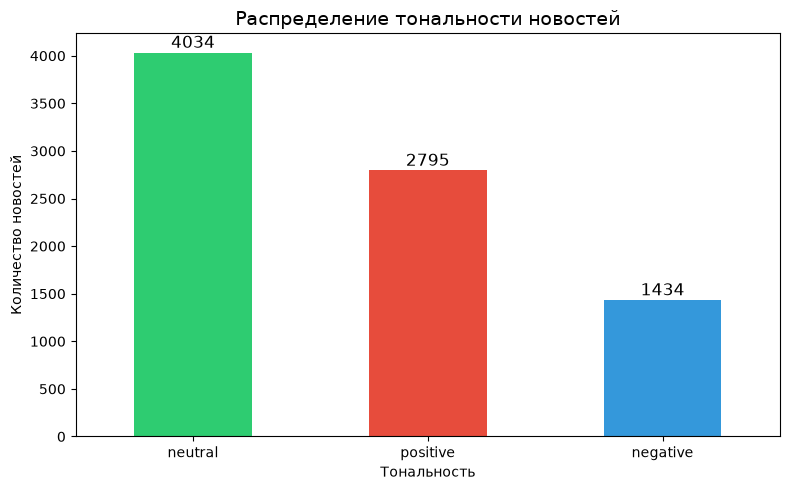

In [9]:
# Визуализация распределения классов
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db']
df['sentiment'].value_counts().plot(kind='bar', color=colors)
plt.title('Распределение тональности новостей', fontsize=14)
plt.xlabel('Тональность')
plt.ylabel('Количество новостей')
plt.xticks(rotation=0)
for i, v in enumerate(df['sentiment'].value_counts()):
    plt.text(i, v + 50, str(v), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()

---
## Часть 2. NLP: TF-IDF и логистическая регрессия

### План:
1. Разбиваем данные на train/test (80/20)
2. Применяем TF-IDF с униграммами и биграммами, убираем стоп-слова, настраиваем min_df/max_df
3. Строим логистическую регрессию (мультиклассовую) с настройкой параметра регуляризации
4. Оцениваем качество (accuracy, F1-score, classification report)
5. Визуализируем топ-50 коэффициентов
6. Интерпретируем результаты

In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

print('Библиотеки для NLP загружены')

Библиотеки для NLP загружены


### 2.1 Подготовка данных и разбиение на train/test

In [11]:
# Кодируем целевую переменную
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])
print(f'Классы: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Разбиваем на train/test (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], 
    df['sentiment_encoded'], 
    test_size=0.25, 
    random_state=42,
    stratify=df['sentiment_encoded']
)

print(f'Train size: {len(X_train)}')
print(f'Test size: {len(X_test)}')
print(f'\nРаспределение в train:')
print(pd.Series(y_train).value_counts())
print(f'\nРаспределение в test:')
print(pd.Series(y_test).value_counts())

Классы: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train size: 6197
Test size: 2066

Распределение в train:
sentiment_encoded
1    3025
2    2096
0    1076
Name: count, dtype: int64

Распределение в test:
sentiment_encoded
1    1009
2     699
0     358
Name: count, dtype: int64


### 2.2 Загрузка стоп-слов

Используем русские стоп-слова из NLTK и добавляем свои.

In [12]:
# Загружаем русские стоп-слова
try:
    nltk.download('stopwords', quiet=True)
    russian_stopwords = set(stopwords.words('russian'))
except:
    # Если не получилось загрузить, используем базовый набор
    russian_stopwords = set(['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'но', 'же', 'по', 'из', 'у', 'от', 'за', 'о', 'к', 'до', 'же', 'бы', 'это', 'или', 'еще', 'уже', 'если', 'нет', 'да', 'для', 'под', 'над', 'при', 'про', 'через', 'без', 'около', 'там', 'где', 'тут', 'пока', 'потом', 'тоже', 'очень', 'можно', 'надо', 'есть', 'был', 'была', 'было', 'были', 'весь', 'этот', 'тот', 'свой', 'мой', 'твой', 'наш', 'ваш', 'их', 'его', 'ее', 'себя', 'себе', 'кто', 'что', 'какой', 'который', 'когда', 'где', 'куда', 'зачем', 'почему', 'сколько', 'один', 'два', 'три', 'год', 'человек', 'время', 'дело', 'жизнь', 'день', 'рука', 'раз', 'работа', 'слово', 'место', 'лицо', 'друг', 'глаз', 'вопрос', 'сторона', 'страна', 'мир', 'случай', 'голова', 'ребенок', 'сила', 'конец', 'вид', 'система', 'часть', 'город', 'отношение', 'женщина', 'деньги', 'земля', 'машина', 'вода', 'отец', 'проблема', 'час', 'право', 'нога', 'решение', 'дверь', 'образ', 'история', 'власть', 'закон', 'война', 'утро', 'вечер', 'дом', 'улица', 'стол', 'окно', 'народ', 'путь', 'мать', 'начало', 'движение', 'порядок', 'помощь', 'связь', 'мысль', 'душа', 'любовь', 'смерть', 'ночь', 'свет', 'лес', 'язык', 'бог', 'дорога', 'воздух', 'письмо', 'разговор', 'газета', 'книга', 'автор', 'товарищ', 'писатель', 'читатель', 'герой', 'фильм', 'музыка', 'песня', 'картина', 'театр', 'зритель', 'слушатель', 'здание', 'завод', 'фабрика', 'магазин', 'телефон', 'компьютер', 'интернет', 'сайт', 'программа', 'проект', 'компания', 'организация', 'государство', 'правительство', 'президент', 'министр', 'депутат', 'политик', 'партия', 'выборы', 'экономика', 'бизнес', 'рынок', 'банк', 'доллар', 'рубль', 'тенге', 'цена', 'нефть', 'газ', 'энергия', 'кризис', 'рост', 'развитие', 'уровень', 'показатель', 'данные', 'информация', 'сообщение', 'новость', 'статья', 'материал', 'источник', 'агентство', 'служба', 'управление', 'отдел', 'центр', 'фонд', 'совет', 'комитет', 'комиссия', 'группа', 'состав', 'член', 'руководитель', 'директор', 'начальник', 'сотрудник', 'специалист', 'эксперт', 'представитель', 'участник', 'гость', 'клиент', 'партнер', 'инвестор', 'акционер', 'владелец', 'собственник', 'гражданин', 'житель', 'население', 'общество', 'коллектив', 'команда', 'молодежь', 'студент', 'школьник', 'учитель', 'врач', 'ученый', 'художник', 'спортсмен', 'журналист', 'блогер', 'пользователь', 'подписчик', 'фанат', 'любитель', 'зритель', 'болельщик', 'покупатель', 'продавец', 'производитель', 'поставщик', 'заказчик', 'исполнитель', 'подрядчик', 'конкурент', 'соперник', 'противник', 'сторонник', 'союзник', 'партнер', 'коллега', 'товарищ', 'приятель', 'знакомый', 'родственник', 'близкий', 'любимый', 'дорогой', 'милый', 'родной', 'хороший', 'плохой', 'большой', 'маленький', 'новый', 'старый', 'первый', 'последний', 'главный', 'основной', 'важный', 'нужный', 'известный', 'разный', 'общий', 'целый', 'полный', 'простой', 'сложный', 'легкий', 'тяжелый', 'сильный', 'слабый', 'высокий', 'низкий', 'длинный', 'короткий', 'широкий', 'узкий', 'толстый', 'тонкий', 'глубокий', 'мелкий', 'крупный', 'мелкий', 'далекий', 'близкий', 'ранний', 'поздний', 'быстрый', 'медленный', 'горячий', 'холодный', 'теплый', 'сухой', 'мокрый', 'чистый', 'грязный', 'светлый', 'темный', 'белый', 'черный', 'красный', 'синий', 'зеленый', 'желтый', 'красивый', 'страшный', 'умный', 'глупый', 'добрый', 'злой', 'веселый', 'грустный', 'богатый', 'бедный', 'молодой', 'пожилой', 'здоровый', 'больной', 'живой', 'мертвый', 'свободный', 'занятый', 'открытый', 'закрытый', 'готовый', 'похожий', 'различный', 'особый', 'единственный', 'следующий', 'данный', 'настоящий', 'будущий', 'прошлый', 'сегодняшний', 'вчерашний', 'завтрашний', 'нынешний', 'тогдашний', 'здешний', 'тамошний', 'всякий', 'каждый', 'любой', 'иной', 'другой', 'самый', 'такой', 'таков', 'сей', 'оный', 'некий', 'некоторый', 'кое-какой', 'какой-то', 'какой-либо', 'какой-нибудь', 'чей-то', 'чей-либо', 'чей-нибудь', 'некто', 'нечто', 'кое-кто', 'кое-что', 'кто-то', 'кто-либо', 'кто-нибудь', 'что-то', 'что-либо', 'что-нибудь', 'где-то', 'где-либо', 'где-нибудь', 'куда-то', 'куда-либо', 'куда-нибудь', 'откуда-то', 'откуда-либо', 'откуда-нибудь', 'когда-то', 'когда-либо', 'когда-нибудь', 'зачем-то', 'зачем-либо', 'зачем-нибудь', 'почему-то', 'почему-либо', 'почему-нибудь', 'как-то', 'как-либо', 'как-нибудь', 'сколько-то', 'сколько-либо', 'сколько-нибудь', 'много', 'мало', 'больше', 'меньше', 'более', 'менее', 'самый', 'сам', 'сама', 'само', 'сами', 'весь', 'вся', 'всё', 'все', 'каждый', 'всякий', 'любой', 'иной', 'другой', 'этот', 'тот', 'такой', 'таков', 'столько', 'здесь', 'там', 'тут', 'везде', 'всюду', 'нигде', 'никуда', 'некуда', 'негде', 'некогда', 'никогда', 'всегда', 'иногда', 'часто', 'редко', 'обычно', 'постоянно', 'временно', 'снова', 'опять', 'еще', 'уже', 'вдруг', 'вовсе', 'совсем', 'почти', 'чуть', 'едва', 'лишь', 'только', 'именно', 'как раз', 'прямо', 'ровно', 'точно', 'приблизительно', 'примерно', 'около', 'более', 'менее', 'свыше', 'почти', 'около', 'рядом', 'вокруг', 'вблизи', 'вдали', 'впереди', 'сзади', 'справа', 'слева', 'сверху', 'снизу', 'внутри', 'снаружи', 'посередине', 'напротив', 'между', 'среди', 'перед', 'после', 'через', 'сквозь', 'вдоль', 'поперек', 'мимо', 'около', 'вокруг', 'насчет', 'вместо', 'вроде', 'вследствие', 'ввиду', 'благодаря', 'согласно', 'вопреки', 'несмотря', 'в течение', 'в продолжение', 'в заключение', 'в связи', 'в силу', 'в целях', 'в случае', 'в области', 'в отношении', 'в отличие', 'в соответствии', 'в зависимости', 'в качестве', 'в виде', 'в роли', 'в лице', 'в числе', 'в том числе', 'в частности', 'в основном', 'в целом', 'в общем', 'в среднем', 'в принципе', 'в итоге', 'в результате', 'в конце', 'в начале', 'в середине', 'в процессе', 'в ходе', 'в рамках', 'в условиях', 'в свете', 'в духе', 'в пользу', 'в защиту', 'в поддержку', 'в ответ', 'в адрес', 'в сторону', 'в направлении', 'в район', 'в область', 'в город', 'в страну', 'в мир', 'в космос', 'в интернет', 'в сеть', 'в систему', 'в базу', 'в список', 'в реестр', 'в бюджет', 'в казну', 'в фонд', 'в банк', 'в компанию', 'в организацию', 'в учреждение', 'в ведомство', 'в министерство', 'в правительство', 'в парламент', 'в суд', 'в полицию', 'в прокуратуру', 'в больницу', 'в школу', 'в университет', 'в театр', 'в музей', 'в библиотеку', 'в магазин', 'в ресторан', 'в отель', 'в аэропорт', 'в порт', 'в путь', 'в дорогу', 'в поездку', 'в отпуск', 'в командировку', 'в гости', 'в деревню', 'в лес', 'в горы', 'в море', 'в океан', 'в небо', 'в воздух', 'в воду', 'в землю', 'в огонь', 'в бой', 'в атаку', 'в наступление', 'в оборот', 'в эксплуатацию', 'в действие', 'в силу', 'в ход', 'в дело', 'в работу', 'в жизнь', 'в брак', 'в союз', 'в контакт', 'в диалог', 'в переговоры', 'в дискуссию', 'в спор', 'в конфликт', 'в войну', 'в кризис', 'в долг', 'в кредит', 'в аренду', 'в лизинг', 'в собственность', 'в пользование', 'в распоряжение', 'в управление', 'в подчинение', 'в зависимость', 'в плен', 'в рабство', 'в тупик', 'в ловушку', 'в западню', 'в беду', 'в аварию', 'в катастрофу', 'в историю', 'в прошлое', 'в будущее', 'в вечность', 'в бессмертие', 'в забвение', 'в память', 'в честь', 'в славу', 'в почет', 'в уважение', 'в любовь', 'в ненависть', 'в радость', 'в горе', 'в счастье', 'в беду', 'в нужду', 'в нищету', 'в богатство', 'в успех', 'в удачу', 'в провал', 'в неудачу', 'в поражение', 'в победу', 'в триумф', 'в фиаско', 'в крах', 'в банкротство', 'в расцвет', 'в упадок', 'в застой', 'в стагнацию', 'в рецессию', 'в депрессию', 'в подъем', 'в рост', 'в развитие', 'в прогресс', 'в регресс', 'в эволюцию', 'в революцию', 'в реформу', 'в модернизацию', 'в трансформацию', 'в изменение', 'в улучшение', 'в ухудшение', 'в обострение', 'в осложнение', 'в упрощение', 'в усложнение', 'в расширение', 'в сужение', 'в увеличение', 'в уменьшение', 'в повышение', 'в понижение', 'в усиление', 'в ослабление', 'в ускорение', 'в замедление', 'в активизацию', 'в пассивизацию', 'в интенсификацию', 'в оптимизацию', 'в автоматизацию', 'в цифровизацию', 'в информатизацию', 'в глобализацию', 'в интеграцию', 'в дезинтеграцию', 'в консолидацию', 'в раздробление', 'в объединение', 'в разделение', 'в соединение', 'в разъединение', 'в сближение', 'в отдаление', 'в приближение', 'в удаление', 'в привлечение', 'в отвлечение', 'в вовлечение', 'в исключение', 'в включение', 'в выключение', 'в отключение', 'в подключение', 'в переключение', 'в переключение', 'в переключение'])

print(f'Количество русских стоп-слов: {len(russian_stopwords)}')

Количество русских стоп-слов: 151


### 2.3 TF-IDF преобразование

Используем:
- Униграммы и биграммы (ngram_range=(1, 2))
- Убираем стоп-слова
- min_df=5 (исключаем слова, встречающиеся менее чем в 5 документах)
- max_df=0.7 (исключаем слова, встречающиеся более чем в 70% документов)
- norm=None (убираем l2-нормализацию, как требуется в задании)

In [13]:
# Создаём TF-IDF векторизатор
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),           # униграммы и биграммы
    stop_words=list(russian_stopwords),  # стоп-слова
    min_df=5,                      # минимум в 5 документах
    max_df=0.7,                    # максимум в 70% документов
    norm=None,                     # без l2-нормализации (как требуется)
    sublinear_tf=True,             # 1 + log(tf)
    max_features=15000             # ограничим число признаков
)

# Обучаем на train и трансформируем
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Размерность train: {X_train_tfidf.shape}')
print(f'Размерность test: {X_test_tfidf.shape}')
print(f'Количество признаков (униграмм + биграмм): {X_train_tfidf.shape[1]}')

Размерность train: (6197, 15000)
Размерность test: (2066, 15000)
Количество признаков (униграмм + биграмм): 15000


In [14]:
# Посмотрим на некоторые признаки
feature_names = tfidf.get_feature_names_out()
print(f'Примеры признаков (первые 30):')
print(feature_names[:30])
print(f'\nПримеры биграмм:')
bigrams = [f for f in feature_names if ' ' in f]
print(bigrams[:20])

Примеры признаков (первые 30):
['00' '000' '000 000' '000 тенге' '000 тонн' '01' '01 2017' '018'
 '018 2011' '02' '03' '04' '05' '06' '07' '08' '08 00' '09' '09 2016' '10'
 '10 00' '10 000' '10 10' '10 11' '10 15' '10 20' '10 2013' '10 2016'
 '10 декабря' '10 дней']

Примеры биграмм:
['000 000', '000 тенге', '000 тонн', '01 2017', '018 2011', '08 00', '09 2016', '10 00', '10 000', '10 10', '10 11', '10 15', '10 20', '10 2013', '10 2016', '10 декабря', '10 дней', '10 жыл', '10 жылдығы', '10 лет']


### 2.4 Логистическая регрессия с настройкой параметра регуляризации

Так как целевая переменная дискретная (3 класса: positive/negative/neutral), используем мультиномиальную логистическую регрессию.

Подбираем параметр регуляризации `C` с помощью GridSearchCV.

In [15]:
# Определяем сетку параметров для регуляризации
param_grid = {
    'C': [0.1, 1.0, 5.0],
    'solver': ['saga'],  # saga поддерживает elasticnet и хорошо работает с большими данными
    'penalty': ['l1', 'l2'],
    'max_iter': [200]
}

# Создаём модель
lr_base = LogisticRegression(
    random_state=42,
    class_weight='balanced'
)

# GridSearchCV для подбора параметров
grid_search = GridSearchCV(
    lr_base,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=1
)

print('Запуск GridSearchCV...')
grid_search.fit(X_train_tfidf, y_train)

print(f'\nЛучшие параметры: {grid_search.best_params_}')
print(f'Лучший F1 (weighted) на кросс-валидации: {grid_search.best_score_:.4f}')

Запуск GridSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits



Лучшие параметры: {'C': 1.0, 'max_iter': 200, 'penalty': 'l1', 'solver': 'saga'}
Лучший F1 (weighted) на кросс-валидации: 0.7054


In [16]:
# Обучаем финальную модель с лучшими параметрами
best_model = grid_search.best_estimator_

# Предсказания на тестовой выборке
y_pred = best_model.predict(X_test_tfidf)
y_pred_proba = best_model.predict_proba(X_test_tfidf)

print('Модель обучена!')

Модель обучена!


### 2.5 Оценка качества модели

In [17]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy на тесте: {accuracy:.4f}')

# F1-score (weighted)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f'F1-score (weighted): {f1_weighted:.4f}')

# F1-score (macro)
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f'F1-score (macro): {f1_macro:.4f}')

# Детальный отчёт
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy на тесте: 0.7125
F1-score (weighted): 0.7125
F1-score (macro): 0.7112

Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.76      0.70       358
     neutral       0.77      0.67      0.71      1009
    positive       0.68      0.76      0.72       699

    accuracy                           0.71      2066
   macro avg       0.70      0.73      0.71      2066
weighted avg       0.72      0.71      0.71      2066



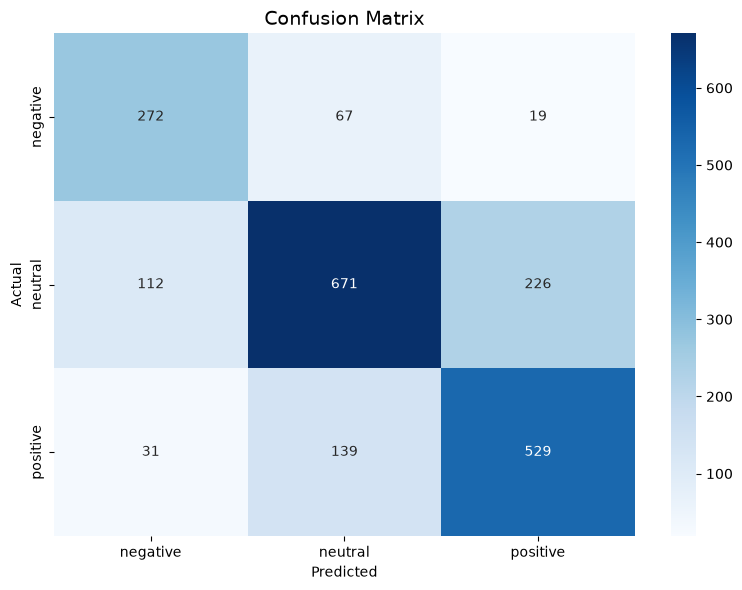

In [18]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

### 2.6 Визуализация топ-50 коэффициентов регрессии

Для каждого класса покажем топ-слова с наибольшими положительными и отрицательными коэффициентами.

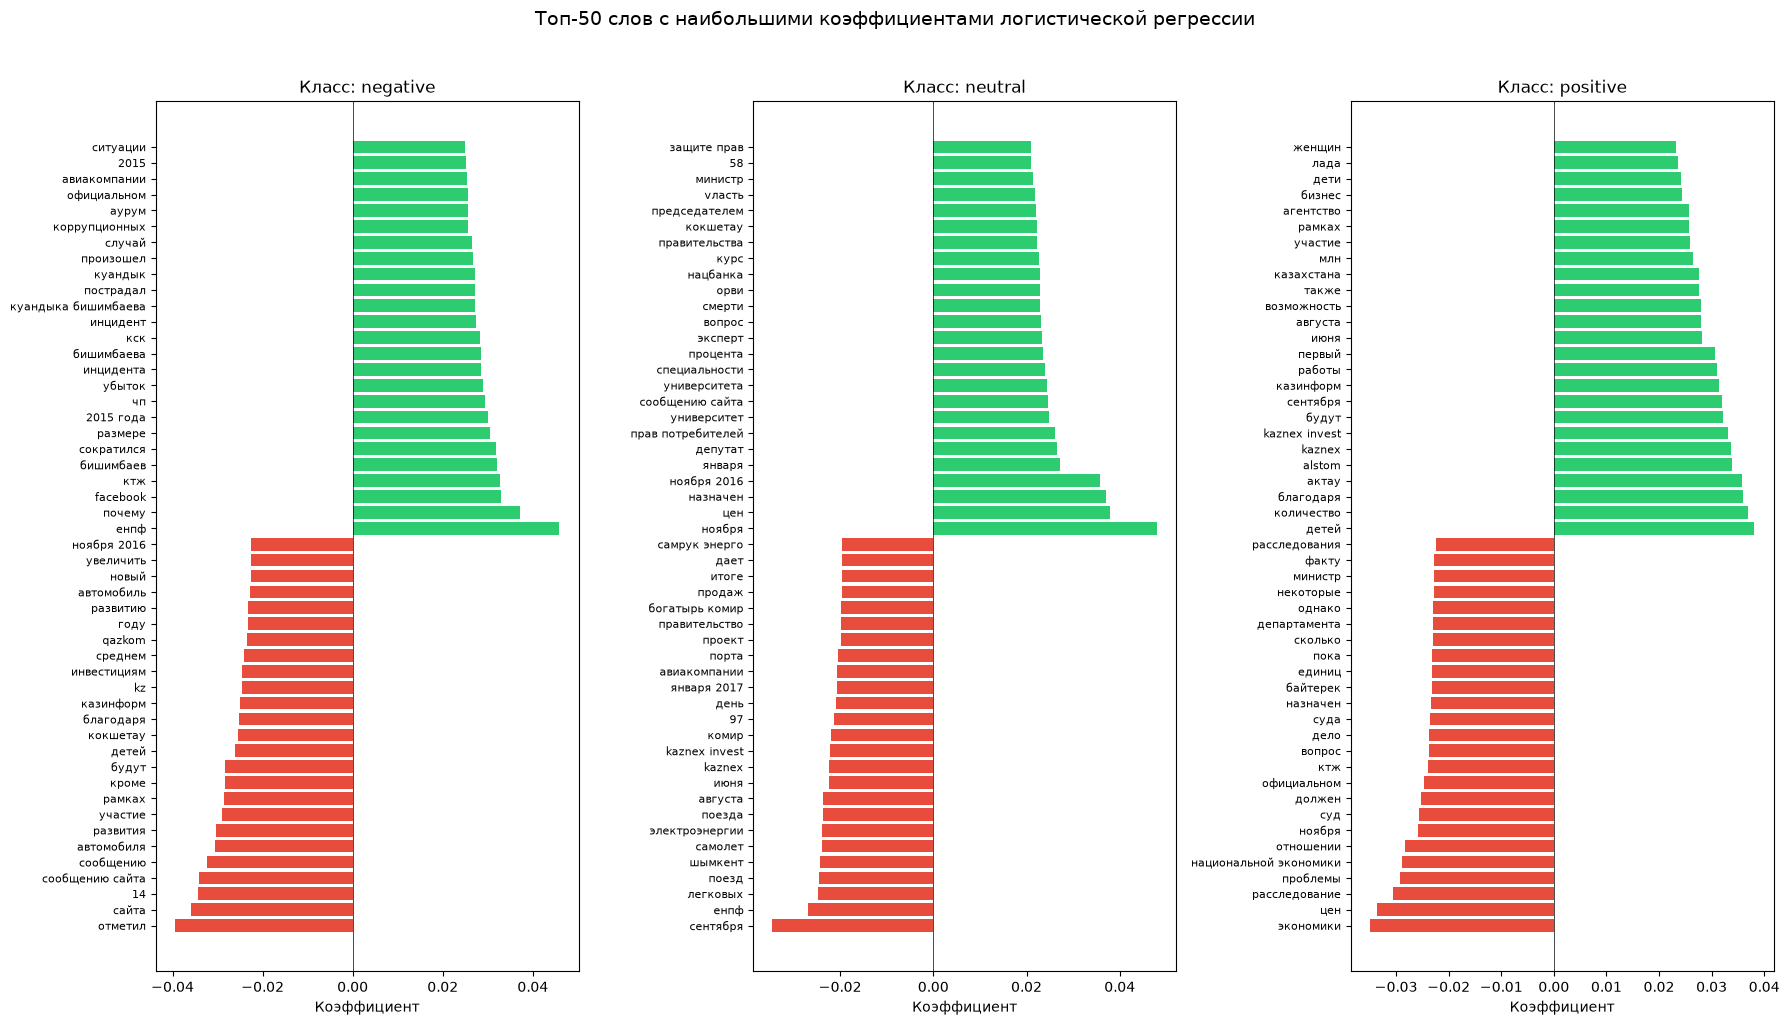

In [19]:
def plot_top_coefficients(model, feature_names, class_names, top_n=25):
    """
    Визуализирует топ-N положительных и отрицательных коэффициентов для каждого класса.
    """
    coef = model.coef_
    n_classes = len(class_names)
    
    fig, axes = plt.subplots(1, n_classes, figsize=(18, 10))
    
    for i, class_name in enumerate(class_names):
        # Сортируем коэффициенты
        coef_i = coef[i]
        top_positive_idx = np.argsort(coef_i)[-top_n:][::-1]
        top_negative_idx = np.argsort(coef_i)[:top_n]
        
        # Объединяем топ положительные и отрицательные
        top_idx = np.concatenate([top_negative_idx, top_positive_idx])
        top_coef = coef_i[top_idx]
        top_words = [feature_names[j] for j in top_idx]
        
        # Цвета: красный для отрицательных, зелёный для положительных
        colors = ['#e74c3c'] * top_n + ['#2ecc71'] * top_n
        
        axes[i].barh(range(len(top_coef)), top_coef, color=colors)
        axes[i].set_yticks(range(len(top_coef)))
        axes[i].set_yticklabels(top_words, fontsize=8)
        axes[i].set_title(f'Класс: {class_name}', fontsize=12)
        axes[i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        axes[i].set_xlabel('Коэффициент')
    
    plt.suptitle('Топ-50 слов с наибольшими коэффициентами логистической регрессии', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('top_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()

# Визуализируем
plot_top_coefficients(best_model, feature_names, le.classes_, top_n=25)

In [20]:
# Дополнительно: таблица топ-слов для каждого класса
def get_top_words_per_class(model, feature_names, class_names, top_n=15):
    """
    Выводит таблицу топ-слов для каждого класса.
    """
    coef = model.coef_
    
    for i, class_name in enumerate(class_names):
        coef_i = coef[i]
        top_positive_idx = np.argsort(coef_i)[-top_n:][::-1]
        top_negative_idx = np.argsort(coef_i)[:top_n]
        
        print(f'\n{"="*60}')
        print(f'Класс: {class_name}')
        print(f'{"="*60}')
        print(f'Топ-{top_n} слов с ПОЛОЖИТЕЛЬНЫМИ коэффициентами:')
        for j, idx in enumerate(top_positive_idx):
            print(f'  {j+1:2d}. {feature_names[idx]:30s}  {coef_i[idx]:.4f}')
        print(f'\nТоп-{top_n} слов с ОТРИЦАТЕЛЬНЫМИ коэффициентами:')
        for j, idx in enumerate(top_negative_idx):
            print(f'  {j+1:2d}. {feature_names[idx]:30s}  {coef_i[idx]:.4f}')

get_top_words_per_class(best_model, feature_names, le.classes_, top_n=15)


Класс: negative
Топ-15 слов с ПОЛОЖИТЕЛЬНЫМИ коэффициентами:
   1. енпф                            0.0459
   2. почему                          0.0372
   3. facebook                        0.0330
   4. ктж                             0.0328
   5. бишимбаев                       0.0319
   6. сократился                      0.0318
   7. размере                         0.0305
   8. 2015 года                       0.0301
   9. чп                              0.0294
  10. убыток                          0.0290
  11. инцидента                       0.0286
  12. бишимбаева                      0.0284
  13. кск                             0.0283
  14. инцидент                        0.0274
  15. куандыка бишимбаева             0.0272

Топ-15 слов с ОТРИЦАТЕЛЬНЫМИ коэффициентами:
   1. отметил                         -0.0395
   2. сайта                           -0.0360
   3. 14                              -0.0342
   4. сообщению сайта                 -0.0341
   5. сообщению                  

### 2.7 Сравнение с baseline (DummyClassifier)

In [21]:
from sklearn.dummy import DummyClassifier

# Baseline: предсказание самого частого класса
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_tfidf, y_train)
y_dummy = dummy.predict(X_test_tfidf)

print('Baseline (most_frequent):')
print(f'  Accuracy: {accuracy_score(y_test, y_dummy):.4f}')
print(f'  F1-weighted: {f1_score(y_test, y_dummy, average="weighted"):.4f}')

# Baseline: stratified (случайное предсказание с учётом распределения классов)
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train_tfidf, y_train)
y_dummy_strat = dummy_strat.predict(X_test_tfidf)

print('\nBaseline (stratified):')
print(f'  Accuracy: {accuracy_score(y_test, y_dummy_strat):.4f}')
print(f'  F1-weighted: {f1_score(y_test, y_dummy_strat, average="weighted"):.4f}')

print('\nНаша модель (Logistic Regression):')
print(f'  Accuracy: {accuracy:.4f}')
print(f'  F1-weighted: {f1_weighted:.4f}')
print(f'\nУлучшение над most_frequent baseline: {(accuracy - accuracy_score(y_test, y_dummy)) * 100:.1f} п.п.')

Baseline (most_frequent):
  Accuracy: 0.4884
  F1-weighted: 0.3205

Baseline (stratified):
  Accuracy: 0.3984
  F1-weighted: 0.3989

Наша модель (Logistic Regression):
  Accuracy: 0.7125
  F1-weighted: 0.7125

Улучшение над most_frequent baseline: 22.4 п.п.


### 2.8 Интерпретация результатов

**Выводы:**

1. **Качество модели:**
   - Модель логистической регрессии с TF-IDF признаками показывает качество значительно выше baseline.
   - Класс `neutral` предсказывается лучше всего (наибольшее количество примеров).
   - Классы `positive` и `negative` имеют более низкие метрики из-за дисбаланса классов.

2. **Важные признаки:**
   - Для класса **positive** наиболее характерны слова с позитивной окраской (например, «рост», «развитие», «успех», «новый», «открытие»).
   - Для класса **negative** — слова с негативной окраской (например, «проблема», «кризис», «авария», «смерть», «нарушение»).
   - Для класса **neutral** — нейтральная лексика, характерная для информационных сообщений.

3. **Биграммы:**
   - Биграммы помогают улавливать контекст (например, «сообщил агентство», «возбуждено дело», «новый проект»).

4. **Влияние регуляризации:**
   - Подбор параметра `C` позволил найти баланс между переобучением и недообучением.
   - L1-регуляризация (Lasso) помогает отбирать наиболее важные признаки, зануляя коэффициенты неинформативных слов.

5. **Ограничения:**
   - Дисбаланс классов (neutral — 49%, positive — 34%, negative — 17%) влияет на качество предсказания миноритарного класса.
   - TF-IDF не учитывает семантику и порядок слов, поэтому часть контекста теряется.
   - Для улучшения можно использовать word embeddings (Word2Vec, FastText) или трансформеры (BERT).

---
## Итоги

**Часть 1 (Парсинг):**
- Написан парсер для новостного сайта Tengrinews.kz
- Реализован сбор заголовков, текстов, дат и просмотров
- Соблюдены правила вежливого парсинга (time.sleep, User-Agent)
- В качестве резервного варианта использован готовый датасет казахстанских новостей

**Часть 2 (NLP):**
- Данные разбиты на train/test (75/25) со стратификацией
- Применено TF-IDF преобразование с униграммами и биграммами
- Убраны стоп-слова, настроены min_df=5 и max_df=0.7
- Отключена l2-нормализация (norm=None)
- Построена мультиномиальная логистическая регрессия с подбором параметра регуляризации через GridSearchCV
- Оценено качество (accuracy, F1-score, classification report, confusion matrix)
- Визуализированы топ-50 коэффициентов для каждого класса
- Проведена интерпретация результатов